In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib
from functools import partial

In [92]:
import eoc_eod_functions
import analytical_functions
importlib.reload(analytical_functions)
importlib.reload(eoc_eod_functions)
from eoc_eod_functions import *
from analytical_functions import *

In [88]:
## Load MetaData
cap_tests = pd.read_excel('/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/00_Metadata/Capacity_Tests.xlsx')
systems_md = pd.read_excel('/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/00_Metadata/Metadata_Systems.xlsx')

In [4]:
systems_md.head(6)

,ID,Capacity_nominal_in_Ah,Voltage_nominal_in_V,Energy_nominal_in_kWh,Energy_usable_datasheet_in_kWh,Cell_number_in_series,Cell_number_in_parallel,Cell_number,Inverter_nominal_power,Manufacturer,Chemistry,Chemistry_detail,Date_storage_system_installation,Date_measurement_system_installation
0,1,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1426201200,1436486400
1,2,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1418943600,1450706306
2,3,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1431640800,1464048000
3,4,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1453244400,1466546400
4,5,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1416610800,1471384800
5,6,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1411336800,1473685200


In [5]:
op_datapath_6 = '/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/01_Operational_Data/Data_ID_06/06'
op_datapath_7 = '/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/01_Operational_Data/Data_ID_07/07'


In [6]:
y=2016
m=10
sample_data = pd.read_csv(f'{op_datapath_6}/{y}_{m:02d}_System_ID_06.csv')
# Apply time processing to get seconds and time in datetime format
sample_data = process_time(sample_data)


In [7]:
# Scale to cell level
sample_data = cell_level_scaling(sample_data, systems_md, cell_id=6)

In [8]:
_, cell_capacity_ah = cell_level_info(systems_md, cell_id=6)

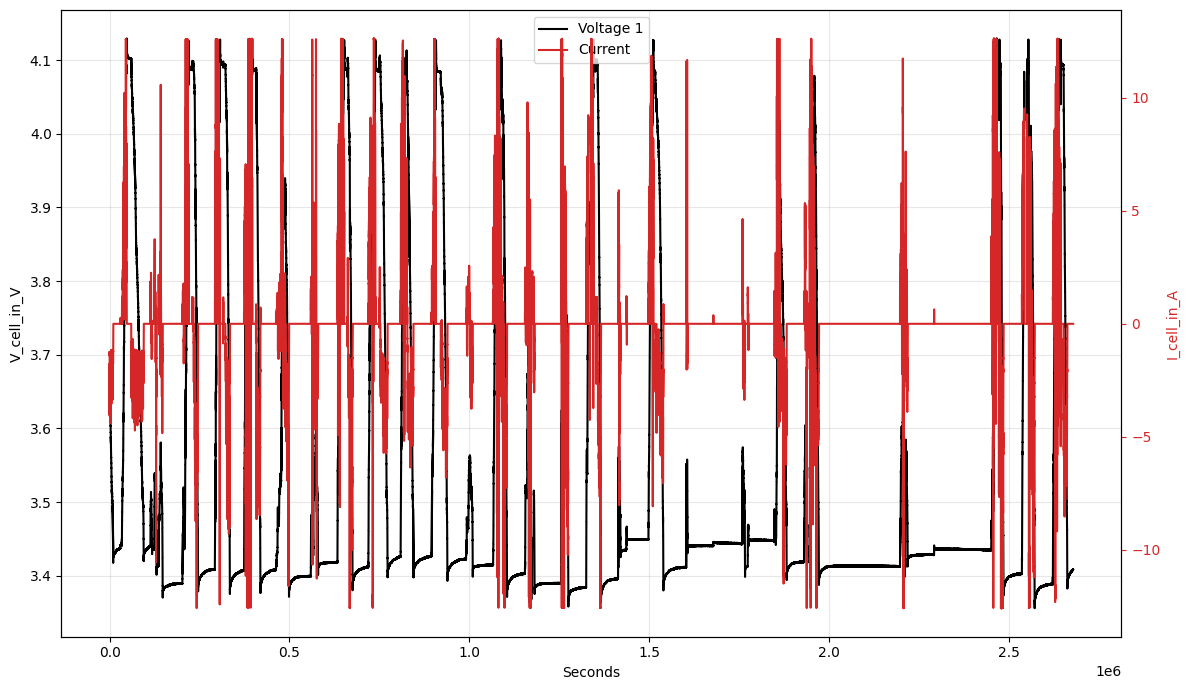

In [150]:
column_map = {1: 'V_cell_in_V', 2: 'I_cell_in_A'}
plot_multi_axis(sample_data, column_map, ('Voltage 1', 'Current'), x='Seconds')
plt.show()

## SOC Calculaton stuff

In [151]:
max_V = sample_data['V_cell_in_V'].max()
min_V = sample_data['V_cell_in_V'].min()
print(f'Max Voltage: {max_V:.2f} V, Min Voltage: {min_V:.2f} V')

Max Voltage: 4.13 V, Min Voltage: 3.36 V


In [53]:
# Find time corresponding times to max and min V which I can associate with the 100 and 0 SOC points for the coulomb counting method
max_V_time = sample_data[sample_data['V_cell_in_V'] == max_V]['Seconds'].iloc[0]
min_V_time = sample_data[sample_data['V_cell_in_V'] == min_V]['Seconds'].iloc[0]
print(f'Time at Max Voltage: {max_V_time} s, Time at Min Voltage: {min_V_time} s')

Time at Max Voltage: 5302.0 s, Time at Min Voltage: 1176166.0 s


In [95]:
# Use these times as anchor points for the coulomb counting method to get SOC profile over the entire time range
soc_vmin = coulomb_count_bidirectional(
    sample_data, 
    capacity_ah=cell_capacity_ah, 
    anchor_time=min_V_time,
    anchor_soc=.1,
    clip_soc=False
)

soc_vmax = coulomb_count_bidirectional(
    sample_data, 
    capacity_ah=cell_capacity_ah, 
    anchor_time=max_V_time,
    anchor_soc=.8,
    clip_soc=False
)

In [96]:
sample_data['SOC_vmin'] = soc_vmin
sample_data['SOC_vmax'] = soc_vmax

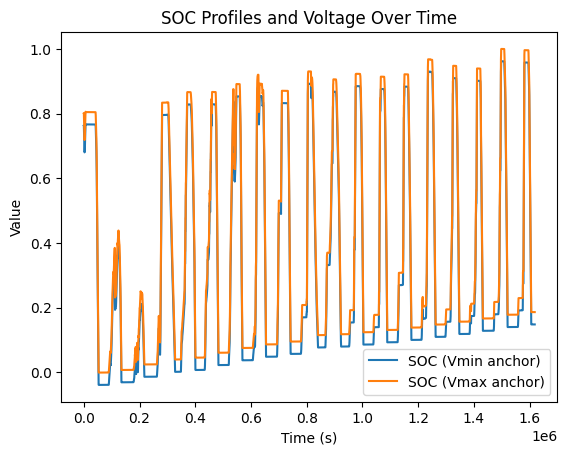

In [97]:
plt.plot(sample_data['Seconds'], sample_data['SOC_vmin'], label='SOC (Vmin anchor)')
plt.plot(sample_data['Seconds'], sample_data['SOC_vmax'], label='SOC (Vmax anchor)')
# plt.plot(sample_data['Seconds'], sample_data['V_cell_in_V'], label='Voltage')
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('SOC Profiles and Voltage Over Time')
plt.legend()
plt.show()

In [85]:
sample_data[['I_in_A', 'I_cell_in_A']].head()

,I_in_A,I_cell_in_A
0,0.228455,0.228455
1,0.228456,0.228456
2,0.228458,0.228458
3,0.228460,0.228460
4,0.228461,0.228461


### Simple implementation: Calculate the throughput between the max and min voltage for each month and see how it looks

In [8]:
# Create a pipeline for cell level processing and throughput computation
def pipeline(df, ops):
    for op in ops:
        df = op(df)
    return df

In [ ]:
op1 = partial(cell_level_scaling, metadata=systems_md, cell_id=6)
op2 = partial(compute_ah_throughput)

combined_ops = lambda df: pipeline(df, [op1, op2])

processing_results = load_and_operate(
    folder_path=op_datapath_6,
    start_year=2022,
    end_year=2022,
    cellID=6,
    month=None,
    print_missing=True,
    operation=combined_ops
)

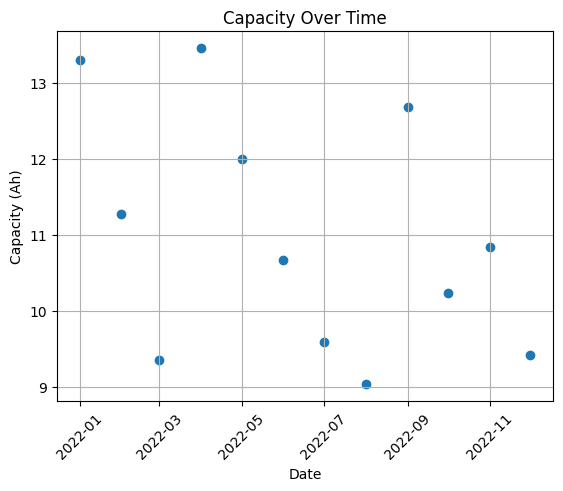

In [202]:
# Plot capacity scatter plot
dates = [pd.to_datetime(k, format='%Y_%m') for k in processing_results.keys()]
capacities = list(processing_results.values())

plt.scatter(dates, capacities)
plt.xlabel('Date')
plt.ylabel('Capacity (Ah)')
plt.title('Capacity Over Time')
plt.xticks(rotation=45)
plt.grid(True)
# To save:
# plt.savefig('<filename>.png', dpi=600, bbox_inches='tight')
plt.show()


## Use a 20-80 SOC Range and calculate throughput in between

In [10]:
sample_segments = detect_soc_window_segments(sample_data, year=2016, month=10)

In [17]:
sample_segments['lower_segments'][0]

(np.float64(2780.0), np.float64(2784.0))

In [45]:
high_peaks, low_peaks = detect_voltage_peaks(sample_data['Seconds'], sample_data['V_cell_in_V'], v_high=4.1, v_low=3.4)

In [46]:
high_peaks[:,1]

array([4.1293  , 4.12615 , 4.12525 , 4.127925, 4.128925, 4.127175,
       4.127775, 4.1132  , 4.127025, 4.126975, 4.127625, 4.1273  ,
       4.129275, 4.12785 , 4.12795 , 4.128325])

/home/tamoghna/miniconda3/envs/mehran_proj/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


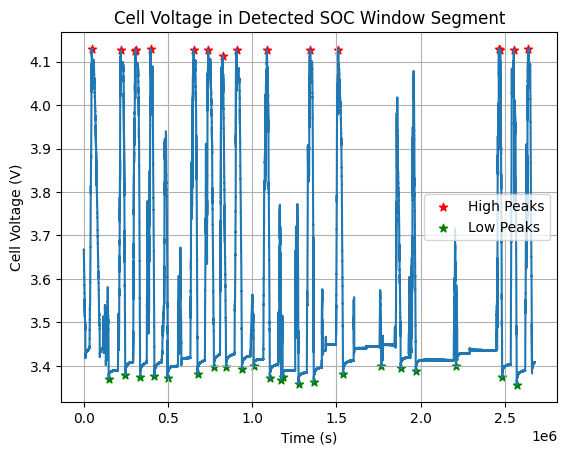

In [ ]:
plt.plot(sample_data['Seconds'], sample_data['V_cell_in_V'])
plt.scatter(high_peaks[:,0], high_peaks[:,1], marker = '*', color='red', label='High Peaks')
plt.scatter(low_peaks[:,0], low_peaks[:,1], marker = '*', color='green', label='Low Peaks')
plt.scatter(h2l_filtered[:,0], h2l_filtered[:,1], marker = 'o', color='blue', label='H2L Pairs')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Cell Voltage (V)')
plt.title('Cell Voltage in Detected SOC Window Segment')
plt.grid(True)
plt.show()

In [51]:
h2l, l2h = pair_peaks(high_peaks, low_peaks)

In [82]:
np.sort(np.diff(l2h, axis=1), axis=0)

array([[ 52750.],
       [ 58412.],
       [ 62143.],
       [ 62580.],
       [ 63069.],
       [ 68734.],
       [ 69130.],
       [ 69894.],
       [ 72158.],
       [ 78495.],
       [145514.],
       [148930.],
       [153467.],
       [163784.],
       [172823.],
       [232869.],
       [240380.],
       [256043.],
       [494417.],
       [584035.],
       [699816.],
       [926742.]])

In [99]:
# filter top 5 h2l based on smallest time difference
h2l_filtered = h2l[np.argsort([t[1] - t[0] for t in h2l])[:5]]
# Add the time difference as a column for better visualization
# h2l_td = [t[1] - t[0] for t in h2l_filtered]
# h2l_filtered = np.hstack((h2l_filtered, np.array(h2l_td).reshape(-1,1)))

l2h_filtered = l2h[np.argsort([t[1] - t[0] for t in l2h])[:5]]
l2h_td = [t[1] - t[0] for t in l2h_filtered]
l2h_filtered = np.hstack((l2h_filtered, np.array(l2h_td).reshape(-1,1)))


In [85]:
h2l_filtered

array([[2473506., 2484886.,   11380.],
       [1087981., 1104824.,   16843.],
       [2554016., 2571392.,   17376.],
       [2466183., 2484886.,   18703.],
       [ 825546.,  844722.,   19176.]])

/tmp/ipykernel_331203/554105977.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


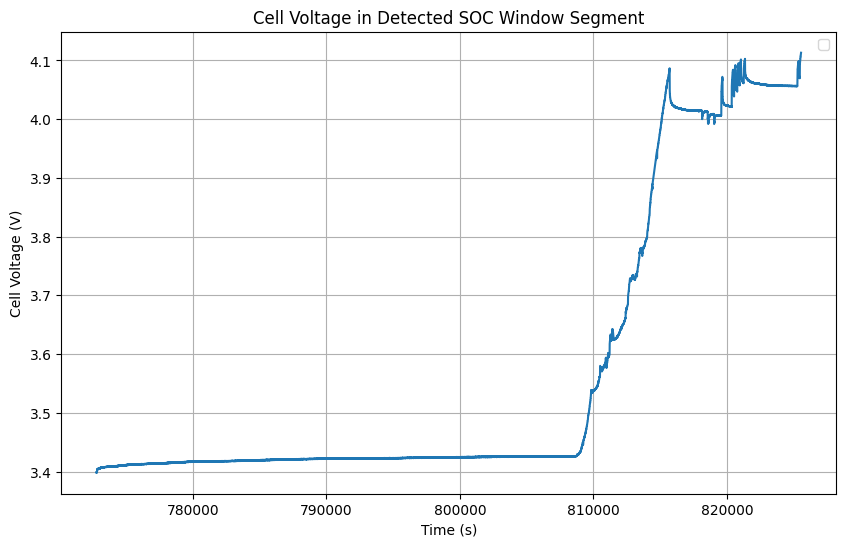

In [75]:
fig, ax = plt.subplots(figsize=(10,6))
for dch_times, ch_times in zip(h2l_filtered, l2h_filtered):
    dch_st = dch_times[0]
    dch_end = dch_times[1]

    ch_st = ch_times[0]
    ch_end = ch_times[1]
    dc_section_data = sample_data[(sample_data['Seconds'] >= dch_st) & (sample_data['Seconds'] <= dch_end)]
    ch_section_data = sample_data[(sample_data['Seconds'] >= ch_st) & (sample_data['Seconds'] <= ch_end)]
    # ax.plot(dc_section_data['Seconds'], dc_section_data['V_cell_in_V'])
    ax.plot(ch_section_data['Seconds'], ch_section_data['V_cell_in_V'])
    break
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Cell Voltage (V)')
plt.title('Cell Voltage in Detected SOC Window Segment')
plt.grid(True)
plt.show()

In [101]:
sample_segments_and_compute_throughput(sample_data, h2l_filtered)

[{'t_start': np.float64(2477532.0),
  't_end': np.float64(2482762.0),
  'v_high': 4.031513612428065,
  'v_low': 3.5519737371406834,
  'throughput_ah': np.float64(10.645047672222221)},
 {'t_start': np.float64(1094562.0),
  't_end': np.float64(1101871.0),
  'v_high': 4.011914944628525,
  'v_low': 3.6143598408761894,
  'throughput_ah': np.float64(7.881473847222221)},
 {'t_start': np.float64(2555406.0),
  't_end': np.float64(2569366.0),
  'v_high': 4.009031414951999,
  'v_low': 3.5744357609540276,
  'throughput_ah': np.float64(9.836016908333333)},
 {'t_start': np.float64(2477594.0),
  't_end': np.float64(2482421.0),
  'v_high': 4.009141465749819,
  'v_low': 3.5566966217016147,
  'throughput_ah': np.float64(9.791556641666666)},
 {'t_start': np.float64(829253.0),
  't_end': np.float64(840233.0),
  'v_high': 4.016620438754861,
  'v_low': 3.6119118853850876,
  'throughput_ah': np.float64(8.483431954166667)}]